# Bangalore House Price

# Introduction

The Bangalore housing market is dynamic and influenced by numerous features such as location, size, number of bedrooms, and availability of amenities. This project aims to leverage machine learning classification techniques to predict whether a property is likely to be purchased based on its features. By building predictive models, we hope to assist potential buyers, real estate agents, and stakeholders in making informed decisions.

# Importing the libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

from tabulate import tabulate
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# Importing the dataset

In [2]:
bangalore_house_price = pd.read_csv(r"/Users/purandarakashyap/Documents/ML, Python and projects/ML Projects/Project 11 (Bangalore house price)/Bengaluru_House_Data.csv")
bangalore_house_price.head()

,property_scope,availability,location,size,society,buying or not buying,BER,Renovation needed,total_sqft,bath,balcony,price
0,Extended Coverage,19-Dec,Electronic City Phase II,2 BED,Coomee,No,A,No,1056,2.0,1.0,39.07
1,Land Parcel,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,No,D,Yes,2600,5.0,3.0,120.00
2,Constructed Space,Ready To Move,Uttarahalli,3 BED,NaN,No,G,Yes,1440,2.0,3.0,62.00
3,Extended Coverage,Ready To Move,Lingadheeranahalli,3 BED,Soiewre,No,G,Yes,1521,3.0,1.0,95.00
4,Extended Coverage,Ready To Move,Kothanur,2 BED,NaN,No,F,Yes,1200,2.0,1.0,51.00


# Initial data exploration

In [3]:
bangalore_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_scope        13320 non-null  object 
 1   availability          13320 non-null  object 
 2   location              13319 non-null  object 
 3   size                  13304 non-null  object 
 4   society               7818 non-null   object 
 5   buying or not buying  13320 non-null  object 
 6   BER                   13320 non-null  object 
 7   Renovation needed     13320 non-null  object 
 8   total_sqft            13320 non-null  object 
 9   bath                  13247 non-null  float64
 10  balcony               12711 non-null  float64
 11  price                 13320 non-null  float64
dtypes: float64(3), object(9)
memory usage: 1.2+ MB


In [4]:
bangalore_house_price.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
bath,13247.000000,2.692610,1.341458,1.000000,2.000000,2.000000,3.000000,40.000000
balcony,12711.000000,1.584376,0.817263,0.000000,1.000000,2.000000,2.000000,3.000000
price,13320.000000,112.565627,148.971674,8.000000,50.000000,72.000000,120.000000,3600.000000


In [5]:
bangalore_house_price.isnull().sum()

property_scope             0
availability               0
location                   1
size                      16
society                 5502
buying or not buying       0
BER                        0
Renovation needed          0
total_sqft                 0
bath                      73
balcony                  609
price                      0
dtype: int64

# Statistical data exploration

# Measures of Central Tendency

In [6]:
skewness_bangalore_house_price = round(bangalore_house_price['price'].skew(), 2)
kurtosis_bangalore_house_price = round(bangalore_house_price['price'].kurt(), 2)
mean_bangalore_house_price = round(bangalore_house_price['price'].mean(), 2)
median_bangalore_house_price = round(bangalore_house_price['price'].median(), 2)

central_data_summary = pd.DataFrame({
    'Metric': ['Skewness', 'Kurtosis', 'Mean', 'Median'],
    'Value': [skewness_bangalore_house_price, kurtosis_bangalore_house_price, mean_bangalore_house_price, median_bangalore_house_price]
})

print("The Measures of Central Tendency summary:\n")
print(tabulate(central_data_summary, headers= 'keys', tablefmt= 'pretty'))

The Measures of Central Tendency summary:

+---+----------+--------+
|   |  Metric  | Value  |
+---+----------+--------+
| 0 | Skewness |  8.06  |
| 1 | Kurtosis | 108.17 |
| 2 |   Mean   | 112.57 |
| 3 |  Median  |  72.0  |
+---+----------+--------+


# Measures of Dispersion

In [7]:
std_var_bangalore_house_price = round(bangalore_house_price['price'].std(), 2)
range_bangalore_house_price = round(bangalore_house_price['price'].max() - (bangalore_house_price['price']).min(), 2)
variance_bangalore_house_price = round(bangalore_house_price['price'].var(), 2)

central_data_summary = pd.DataFrame({
    'Metric': ['Standard Deviation', 'Range', 'Variance'],
    'Value': [std_var_bangalore_house_price, range_bangalore_house_price, variance_bangalore_house_price]
})

print("The Measures of Dispersion summary:\n")
print(tabulate(central_data_summary, headers= 'keys', tablefmt= 'pretty'))

The Measures of Dispersion summary:

+---+--------------------+----------+
|   |       Metric       |  Value   |
+---+--------------------+----------+
| 0 | Standard Deviation |  148.97  |
| 1 |       Range        |  3592.0  |
| 2 |      Variance      | 22192.56 |
+---+--------------------+----------+


# Exploratory data analysis [EDA], before data cleansing

/Users/purandarakashyap/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


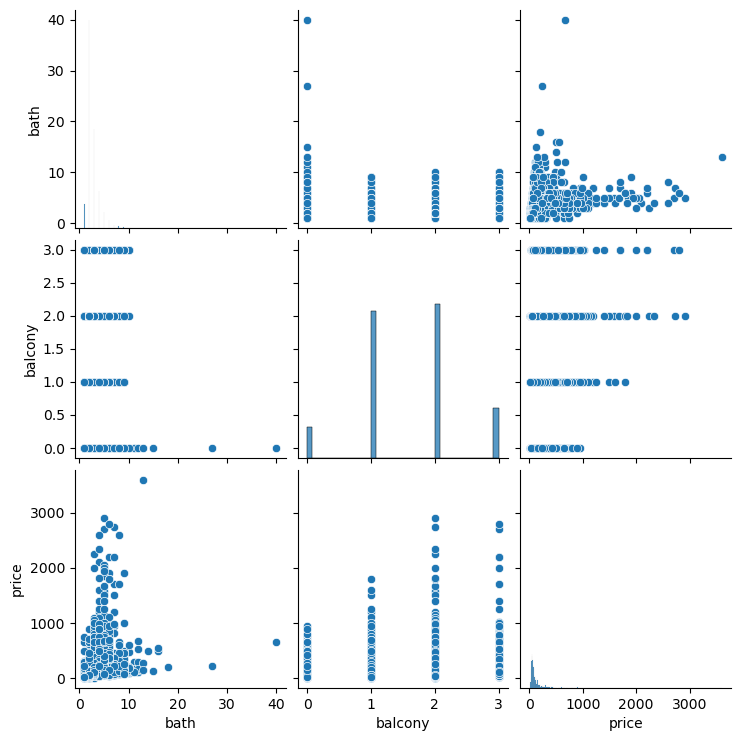

In [8]:
sns.pairplot(bangalore_house_price)
plt.show()

<Axes: >

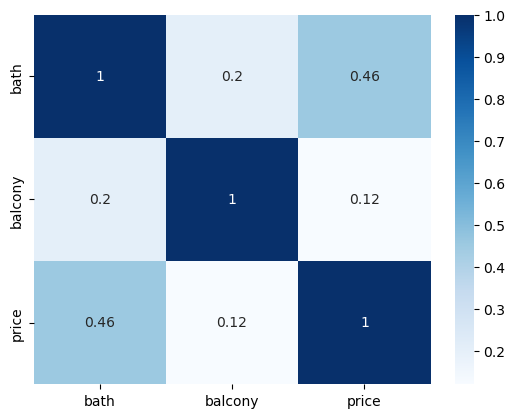

In [9]:
correlation_heat_map = ['bath', 'balcony', 'price']
sns.heatmap(bangalore_house_price[correlation_heat_map].corr(), cmap= 'Blues', annot= True)

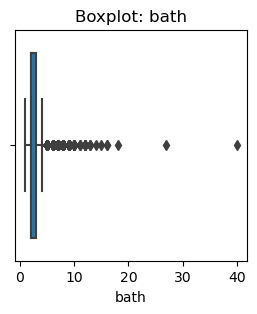

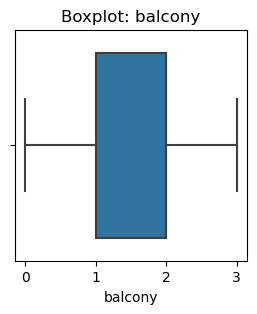

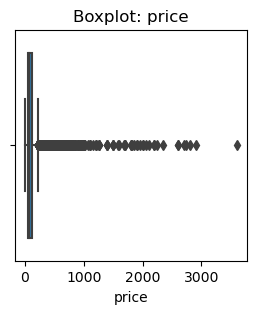

In [10]:
for i in bangalore_house_price.select_dtypes(include= "float").columns:
    plt.figure(figsize= (3, 3))
    sns.boxplot(x= i, data= bangalore_house_price)  
    plt.title(f'Boxplot: {i}')
    plt.show()  

# Data pre-processing

In [11]:
bangalore_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_scope        13320 non-null  object 
 1   availability          13320 non-null  object 
 2   location              13319 non-null  object 
 3   size                  13304 non-null  object 
 4   society               7818 non-null   object 
 5   buying or not buying  13320 non-null  object 
 6   BER                   13320 non-null  object 
 7   Renovation needed     13320 non-null  object 
 8   total_sqft            13320 non-null  object 
 9   bath                  13247 non-null  float64
 10  balcony               12711 non-null  float64
 11  price                 13320 non-null  float64
dtypes: float64(3), object(9)
memory usage: 1.2+ MB


In [12]:
bangalore_house_pricecounts = bangalore_house_price['size'].value_counts().reset_index()
bangalore_house_pricecounts.columns = ['size', 'Counts']

print("Computing the value counts of \"Size\" feature:\n", tabulate(bangalore_house_pricecounts, headers= 'keys', tablefmt= 'pretty'))

Computing the value counts of "Size" feature:
 +----+------------+--------+
|    |    size    | Counts |
+----+------------+--------+
| 0  |   2 BED    |  5199  |
| 1  |   3 BED    |  4310  |
| 2  | 4 Bedroom  |  826   |
| 3  |   4 BED    |  591   |
| 4  |   1 BED    |  551   |
| 5  | 3 Bedroom  |  547   |
| 6  | 2 Bedroom  |  329   |
| 7  | 5 Bedroom  |  297   |
| 8  | 6 Bedroom  |  191   |
| 9  | 1 Bedroom  |  105   |
| 10 | 8 Bedroom  |   84   |
| 11 | 7 Bedroom  |   83   |
| 12 |   5 BED    |   59   |
| 13 | 9 Bedroom  |   46   |
| 14 |   6 BED    |   30   |
| 15 |   7 BED    |   17   |
| 16 | 10 Bedroom |   12   |
| 17 |   9 BED    |   8    |
| 18 |   8 BED    |   5    |
| 19 |   10 BED   |   2    |
| 20 |   11 BED   |   2    |
| 21 | 11 Bedroom |   2    |
| 22 |   19 BED   |   1    |
| 23 |   16 BED   |   1    |
| 24 | 43 Bedroom |   1    |
| 25 |   14 BED   |   1    |
| 26 |   27 BED   |   1    |
| 27 | 12 Bedroom |   1    |
| 28 |   13 BED   |   1    |
| 29 | 18 Bedroom |   1  

In [13]:
bangalore_house_price['location'] = bangalore_house_price['location'].fillna('Other')

In [14]:
size_mapping = {
    '1 Bedroom': 1, '2 BHK': 2, '2 BED': 2, '2 Bedroom': 2, '3 BED': 3, '3 BHK': 3, '3 Bedroom': 3,
    '4 Bedroom': 4, '4 BHK': 4, '5 BHK': 5, '5 Bedroom': 5, '6 Bedroom': 6, '6 BHK': 6,
    '7 BHK': 7, '8 Bedroom': 8, '9 BHK': 9, '10 Bedroom': 10,
    '11 BHK': 11, '11 Bedroom': 11, '12 Bedroom': 12, '13 BHK': 13, '14 BHK': 14,
    '16 BHK': 16, '18 Bedroom': 18, '19 BHK': 19, '43 Bedroom': 43, '4 BED': 4, '1 BED': 1, '7 Bedroom': 7,
    '5 BED': 5, '9 Bedroom': 9, '6 BED': 6, '7 BED': 7, '9 BED': 9, '8 BED': 8, '11 BED': 11, '10 BED': 10, 
    '27 BED': 27, '19 BED': 19, '16 BED': 16, '14 BED': 14, '13 BED': 13
}

bangalore_house_price['size'] = bangalore_house_price['size'].replace(size_mapping)

In [15]:
bangalore_house_pricecounts = bangalore_house_price['size'].value_counts().reset_index()
bangalore_house_pricecounts.columns = ['size', 'Counts']

print("Computing the value counts of \"Size\" feature:\n", tabulate(bangalore_house_pricecounts, headers= 'keys', tablefmt= 'pretty'))

Computing the value counts of "Size" feature:
 +----+------+--------+
|    | size | Counts |
+----+------+--------+
| 0  | 2.0  | 5528.0 |
| 1  | 3.0  | 4857.0 |
| 2  | 4.0  | 1417.0 |
| 3  | 1.0  | 656.0  |
| 4  | 5.0  | 356.0  |
| 5  | 6.0  | 221.0  |
| 6  | 7.0  | 100.0  |
| 7  | 8.0  |  89.0  |
| 8  | 9.0  |  54.0  |
| 9  | 10.0 |  14.0  |
| 10 | 11.0 |  4.0   |
| 11 | 27.0 |  1.0   |
| 12 | 19.0 |  1.0   |
| 13 | 16.0 |  1.0   |
| 14 | 43.0 |  1.0   |
| 15 | 14.0 |  1.0   |
| 16 | 12.0 |  1.0   |
| 17 | 13.0 |  1.0   |
| 18 | 18.0 |  1.0   |
+----+------+--------+


In [16]:
bangalore_house_price['size'].fillna(bangalore_house_price['size'].median(), inplace=True)

In [17]:
bangalore_house_pricecounts = bangalore_house_price['total_sqft'].value_counts().reset_index().tail(10)
bangalore_house_pricecounts.columns = ['total_sqft', 'Counts']

print("Computing the value counts of \"total_sqft\" feature:\n", tabulate(bangalore_house_pricecounts, headers= 'keys', tablefmt= 'pretty'))

Computing the value counts of "total_sqft" feature:
 +------+-------------+--------+
|      | total_sqft  | Counts |
+------+-------------+--------+
| 2107 |    2370     |   1    |
| 2108 |      5      |   1    |
| 2109 |    1004     |   1    |
| 2110 |    5985     |   1    |
| 2111 | 2466 - 2856 |   1    |
| 2112 |    3580     |   1    |
| 2113 |    2461     |   1    |
| 2114 |    1437     |   1    |
| 2115 |    2155     |   1    |
| 2116 |    4689     |   1    |
+------+-------------+--------+


In [18]:
total_sqfeet = []
for str_val in bangalore_house_price['total_sqft']:
  try:
    total_sqfeet.append(float(str_val))
  except:
    try:
      temp = []
      temp = str_val.split('-')
      total_sqfeet.append((float(temp[0]) + float(temp[-1]))/2)
    except:
      total_sqfeet.append(np.nan)

In [19]:
bangalore_house_price = bangalore_house_price.join(pd.DataFrame({'total_sqfeet': total_sqfeet}))
bangalore_house_price.head(100)

,property_scope,availability,location,size,society,buying or not buying,BER,Renovation needed,total_sqft,bath,balcony,price,total_sqfeet
0,Extended Coverage,19-Dec,Electronic City Phase II,2.0,Coomee,No,A,No,1056,2.0,1.0,39.07,1056.00
1,Land Parcel,Ready To Move,Chikka Tirupathi,4.0,Theanmp,No,D,Yes,2600,5.0,3.0,120.00,2600.00
2,Constructed Space,Ready To Move,Uttarahalli,3.0,NaN,No,G,Yes,1440,2.0,3.0,62.00,1440.00
3,Extended Coverage,Ready To Move,Lingadheeranahalli,3.0,Soiewre,No,G,Yes,1521,3.0,1.0,95.00,1521.00
4,Extended Coverage,Ready To Move,Kothanur,2.0,NaN,No,F,Yes,1200,2.0,1.0,51.00,1200.00
5,Extended Coverage,Ready To Move,Whitefield,2.0,DuenaTa,Yes,G,Yes,1170,2.0,1.0,38.00,1170.00
6,Extended Coverage,18-May,Old Airport Road,4.0,Jaades,No,A,No,2732,4.0,NaN,204.00,2732.00
7,Extended Coverage,Ready To Move,Rajaji Nagar,4.0,Brway G,No,F,Yes,3300,4.0,NaN,600.00,3300.00
8,Extended Coverage,Ready To Move,Marathahalli,3.0,NaN,No,A,No,1310,3.0,1.0,63.25,1310.00
9,Land Parcel,Ready To Move,Gandhi Bazar,6.0,NaN,Yes,C,Maybe,1020,6.0,NaN,370.00,1020.00


In [20]:
bangalore_house_price = bangalore_house_price.reset_index(drop=True)

In [21]:
bangalore_house_pricecounts = bangalore_house_price['total_sqfeet'].value_counts().reset_index()
bangalore_house_pricecounts.columns = ['total_sqfeet', 'Counts']

print("Computing the value counts of \"total_sqfeet\" feature:\n", tabulate(bangalore_house_pricecounts, headers= 'keys', tablefmt= 'pretty'))

Computing the value counts of "total_sqfeet" feature:
 +------+--------------+--------+
|      | total_sqfeet | Counts |
+------+--------------+--------+
|  0   |    1200.0    | 843.0  |
|  1   |    1100.0    | 221.0  |
|  2   |    1500.0    | 206.0  |
|  3   |    2400.0    | 196.0  |
|  4   |    600.0     | 180.0  |
|  5   |    1000.0    | 173.0  |
|  6   |    1350.0    | 133.0  |
|  7   |    1050.0    | 123.0  |
|  8   |    1300.0    | 117.0  |
|  9   |    1250.0    | 114.0  |
|  10  |    900.0     | 112.0  |
|  11  |    1400.0    | 108.0  |
|  12  |    1800.0    | 107.0  |
|  13  |    1600.0    | 101.0  |
|  14  |    1150.0    | 101.0  |
|  15  |    1140.0    |  91.0  |
|  16  |    2000.0    |  83.0  |
|  17  |    1450.0    |  71.0  |
|  18  |    1650.0    |  69.0  |
|  19  |    800.0     |  69.0  |
|  20  |    1075.0    |  67.0  |
|  21  |    3000.0    |  66.0  |
|  22  |    1020.0    |  63.0  |
|  23  |    2500.0    |  63.0  |
|  24  |    1125.0    |  60.0  |
|  25  |    1550.0   

In [22]:
bangalore_house_price['total_sqfeet'].fillna(bangalore_house_price['total_sqfeet'].median(), inplace=True)

In [23]:
bangalore_house_price['bath'].fillna(bangalore_house_price['bath'].median(), inplace=True)

In [24]:
bangalore_house_price['balcony'].fillna(bangalore_house_price['balcony'].median(), inplace=True)

In [25]:
bangalore_house_price['price'].fillna(bangalore_house_price['price'].median(), inplace=True)

In [26]:
bangalore_house_price = bangalore_house_price.drop('society', axis=1)

In [27]:
bangalore_house_price = bangalore_house_price.drop('total_sqft', axis=1)

In [28]:
bangalore_house_price.isnull().sum()

property_scope          0
availability            0
location                0
size                    0
buying or not buying    0
BER                     0
Renovation needed       0
bath                    0
balcony                 0
price                   0
total_sqfeet            0
dtype: int64

In [29]:
# Interquartile rage: [Size]

data_q1 = bangalore_house_price['size'].quantile(0.25)
data_q3 = bangalore_house_price['size'].quantile(0.75)

interquartile_range = data_q3 - data_q1

lower_bound_range = data_q1 - 1.5 * interquartile_range
upper_bound_range = data_q3 + 1.5 * interquartile_range

data_outliers = bangalore_house_price[(bangalore_house_price['size'] < lower_bound_range) | (bangalore_house_price['size'] > upper_bound_range)]
data_outliers.shape

(846, 11)

In [30]:
# Interquartile range: [Total sqft]

data_q1 = bangalore_house_price['total_sqfeet'].quantile(0.25)
data_q3 = bangalore_house_price['total_sqfeet'].quantile(0.75)

interquartile_range = data_q3 - data_q1

lower_bound_range = data_q1 - 1.5 * interquartile_range
upper_bound_range = data_q3 + 1.5 * interquartile_range

data_outliers = bangalore_house_price[(bangalore_house_price['total_sqfeet'] < lower_bound_range) | (bangalore_house_price['total_sqfeet'] > upper_bound_range)]
data_outliers.shape

(1172, 11)

In [31]:
# Interquartile range: [Price]

data_q1 = bangalore_house_price['price'].quantile(0.25)
data_q3 = bangalore_house_price['price'].quantile(0.75)

interquartile_range = data_q3 - data_q1

lower_bound_range = data_q1 - 1.5 * interquartile_range
upper_bound_range = data_q3 + 1.5 * interquartile_range

data_outliers = bangalore_house_price[(bangalore_house_price['price'] < lower_bound_range) | (bangalore_house_price['price'] > upper_bound_range)]
data_outliers.shape

(1276, 11)

In [32]:
print("Title: The data points where the total_sqfeet / size < 350 are to handled.\n")
bangalore_house_price.query('total_sqfeet / size < 350').shape
print(f"Before addressing outliers: {bangalore_house_price.query('total_sqfeet / size < 350').shape}")

rows_to_delete = bangalore_house_price.query('total_sqfeet / size < 350').index
bangalore_house_price = bangalore_house_price.drop(rows_to_delete, axis=0).reset_index(drop=True)

bangalore_house_price.query('total_sqfeet / size < 350').shape
print(f"After addressing outliers: {bangalore_house_price.query('total_sqfeet / size < 350').shape}\n")
print("Summary: This allows to handle the extreme data points in the boxplot.")

Title: The data points where the total_sqfeet / size < 350 are to handled.

Before addressing outliers: (1107, 11)
After addressing outliers: (0, 11)

Summary: This allows to handle the extreme data points in the boxplot.


In [33]:
bangalore_house_price['price'] = bangalore_house_price['price'] * 100000 / bangalore_house_price['total_sqfeet']  
bangalore_house_price.head()

,property_scope,availability,location,size,buying or not buying,BER,Renovation needed,bath,balcony,price,total_sqfeet
0,Extended Coverage,19-Dec,Electronic City Phase II,2.0,No,A,No,2.0,1.0,3699.810606,1056.0
1,Land Parcel,Ready To Move,Chikka Tirupathi,4.0,No,D,Yes,5.0,3.0,4615.384615,2600.0
2,Constructed Space,Ready To Move,Uttarahalli,3.0,No,G,Yes,2.0,3.0,4305.555556,1440.0
3,Extended Coverage,Ready To Move,Lingadheeranahalli,3.0,No,G,Yes,3.0,1.0,6245.890861,1521.0
4,Extended Coverage,Ready To Move,Kothanur,2.0,No,F,Yes,2.0,1.0,4250.000000,1200.0


In [34]:
bangalore_house_price.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
size,12213.000000,2.620896,0.944529,1.000000,2.000000,3.000000,3.000000,16.000000
bath,12213.000000,2.534594,1.049645,1.000000,2.000000,2.000000,3.000000,16.000000
balcony,12213.000000,1.608778,0.794405,0.000000,1.000000,2.000000,2.000000,3.000000
price,12213.000000,6185.006421,4018.116728,267.829813,4200.000000,5263.157895,6807.339450,176470.588235
total_sqfeet,12213.000000,1606.237485,1273.156106,350.000000,1124.000000,1307.000000,1710.000000,52272.000000


In [35]:
def remove_pps_outliers(bangalore_house_price):
  data_out = pd.DataFrame()
  for key, subdf in bangalore_house_price.groupby('location'):
    m = np.mean(subdf.price)
    st = np.std(subdf.price)
    reduced_df = subdf[(subdf.price > (m - st)) & (subdf.price <= (m + st))]
    data_out = pd.concat([data_out, reduced_df], ignore_index = True)
  return data_out
 
bangalore_house_price = remove_pps_outliers(bangalore_house_price)
bangalore_house_price.shape

(8990, 11)

In [36]:
columns_list = ['size', 'bath','balcony', 'price', 'total_sqfeet']

def wisker(bangalore_house_price, col):
    quartile_1 = bangalore_house_price[col].quantile(0.25)
    quartile_3 = bangalore_house_price[col].quantile(0.75)
    inter_quartile_range = quartile_3 - quartile_1
    lw = quartile_1 - 1.5 * inter_quartile_range
    uw = quartile_3 + 1.5 * inter_quartile_range
    return lw, uw

for col in columns_list:
    lw, uw = wisker(bangalore_house_price, col)
    bangalore_house_price[col] = np.where(bangalore_house_price[col] < lw, lw, bangalore_house_price[col])
    bangalore_house_price[col] = np.where(bangalore_house_price[col] > uw, uw, bangalore_house_price[col])

bangalore_house_price.shape

(8990, 11)

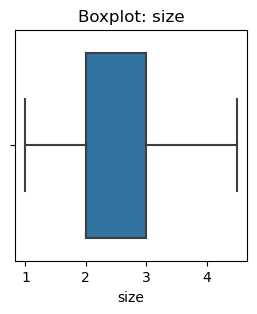

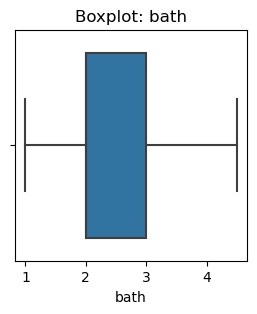

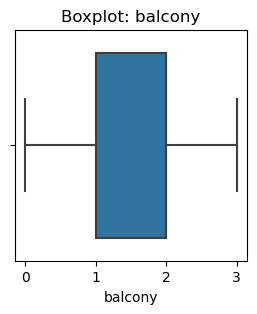

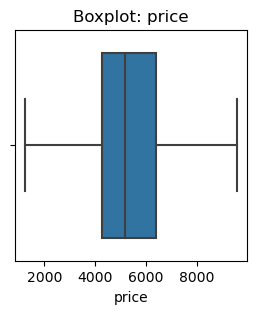

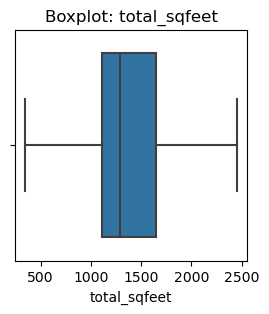

In [37]:
for i in bangalore_house_price.select_dtypes(include= "float").columns:
    plt.figure(figsize= (3, 3))
    sns.boxplot(x= i, data= bangalore_house_price)  
    plt.title(f'Boxplot: {i}')
    plt.show()  

In [38]:
bangalore_house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8990 entries, 0 to 8989
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   property_scope        8990 non-null   object 
 1   availability          8990 non-null   object 
 2   location              8990 non-null   object 
 3   size                  8990 non-null   float64
 4   buying or not buying  8990 non-null   object 
 5   BER                   8990 non-null   object 
 6   Renovation needed     8990 non-null   object 
 7   bath                  8990 non-null   float64
 8   balcony               8990 non-null   float64
 9   price                 8990 non-null   float64
 10  total_sqfeet          8990 non-null   float64
dtypes: float64(5), object(6)
memory usage: 772.7+ KB


In [39]:
bangalore_house_price.head()

,property_scope,availability,location,size,buying or not buying,BER,Renovation needed,bath,balcony,price,total_sqfeet
0,Extended Coverage,Ready To Move,Devarabeesana Halli,3.0,No,A,No,3.0,2.0,8971.291866,1672.0
1,Constructed Space,Ready To Move,Devarabeesana Halli,3.0,No,E,Yes,3.0,3.0,8514.285714,1750.0
2,Extended Coverage,Ready To Move,Devarabeesana Halli,3.0,No,B,Maybe,3.0,2.0,8571.428571,1750.0
3,Extended Coverage,18-May,Devarachikkanahalli,3.0,No,G,Yes,2.0,3.0,3520.000000,1250.0
4,Extended Coverage,Ready To Move,Devarachikkanahalli,2.0,Yes,A,No,2.0,2.0,3200.000000,1250.0


# EDA (After data cleansing)

/Users/purandarakashyap/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


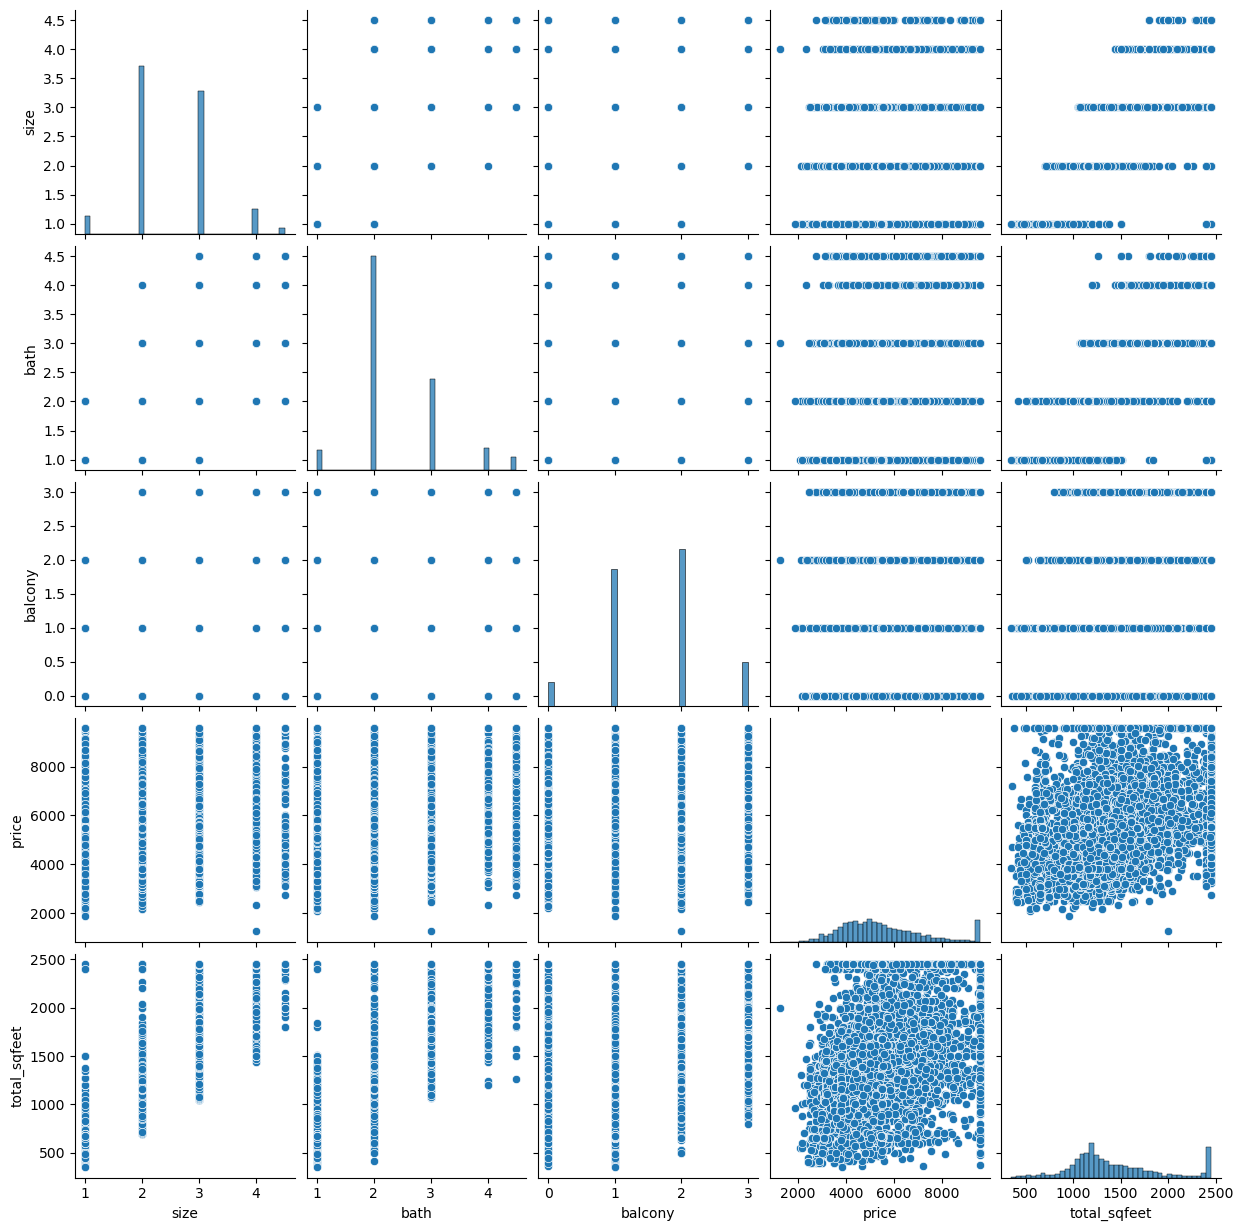

In [40]:
sns.pairplot(bangalore_house_price)
plt.show()

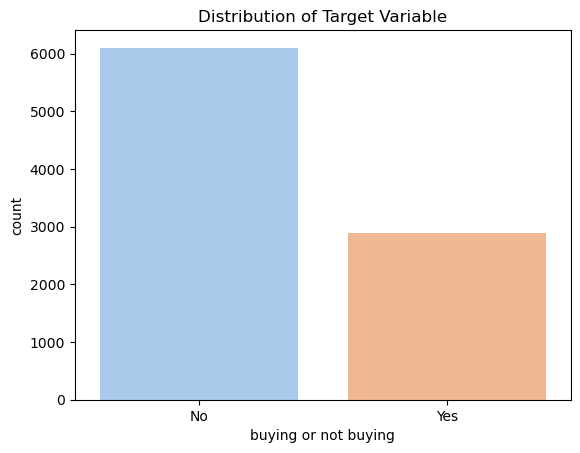

In [41]:
sns.countplot(x='buying or not buying', data=bangalore_house_price, palette="pastel")
plt.title("Distribution of Target Variable")
plt.show()

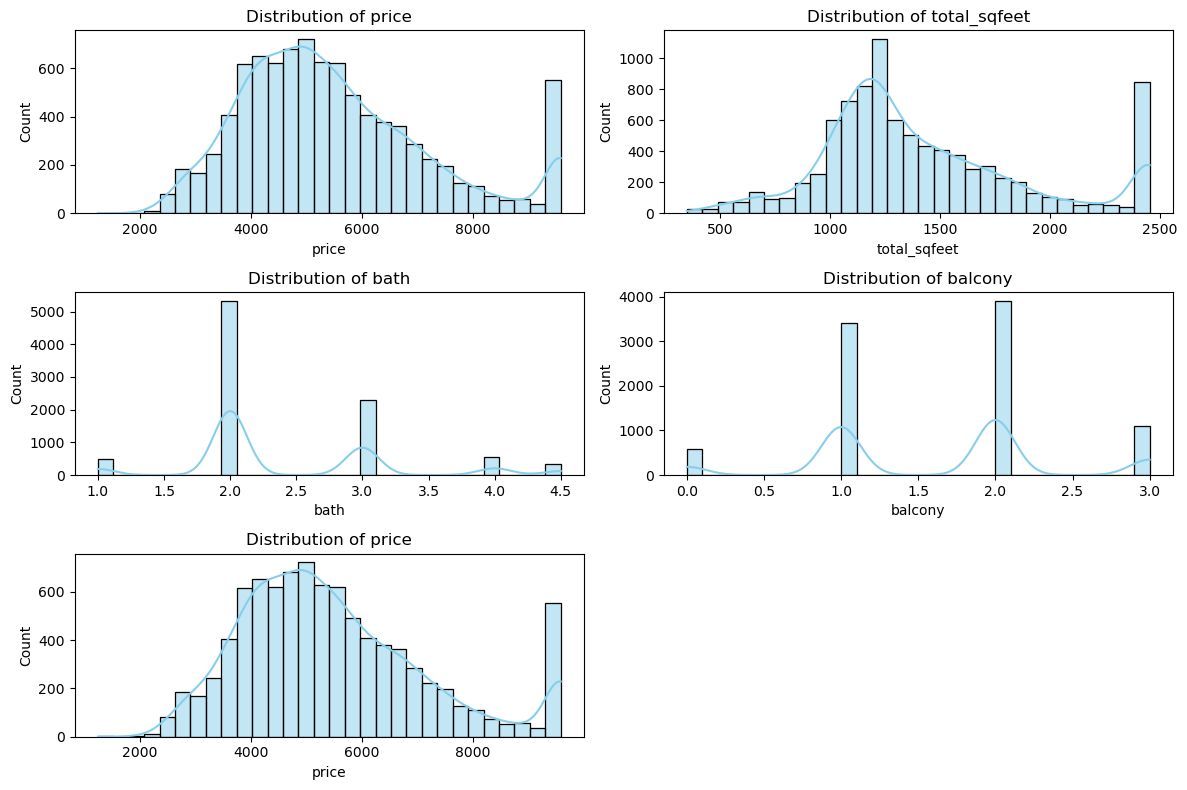

In [42]:
num_cols = ['price', 'total_sqfeet', 'bath', 'balcony', 'price']  # Modify based on dataset

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(bangalore_house_price[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

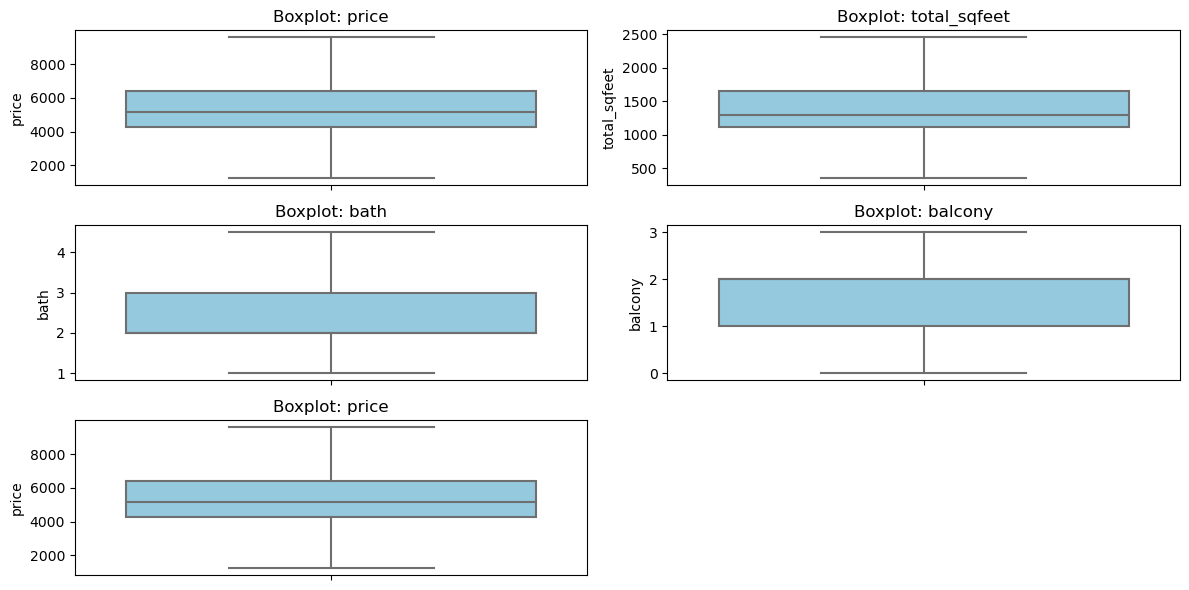

In [43]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(y=bangalore_house_price[col], color="skyblue")
    plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

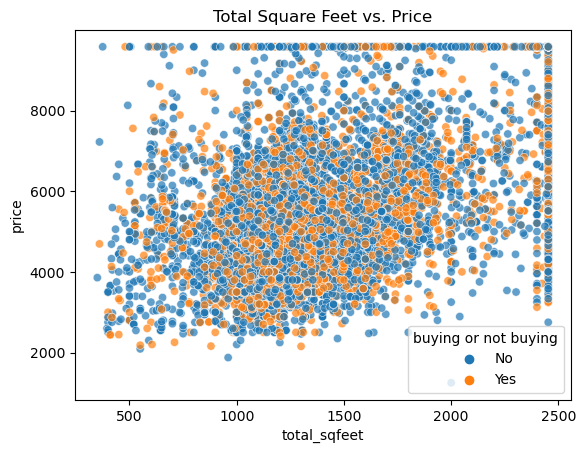

In [44]:
sns.scatterplot(x=bangalore_house_price['total_sqfeet'], y=bangalore_house_price['price'], hue=bangalore_house_price['buying or not buying'], alpha=0.7)
plt.title("Total Square Feet vs. Price")
plt.show()

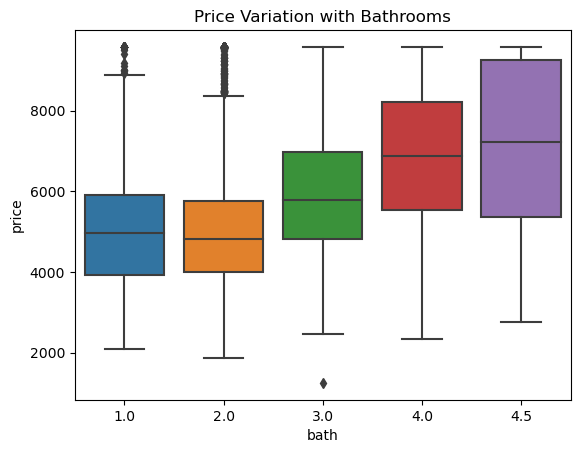

In [45]:
sns.boxplot(x="bath", y="price", data=bangalore_house_price)
plt.title("Price Variation with Bathrooms")
plt.show()

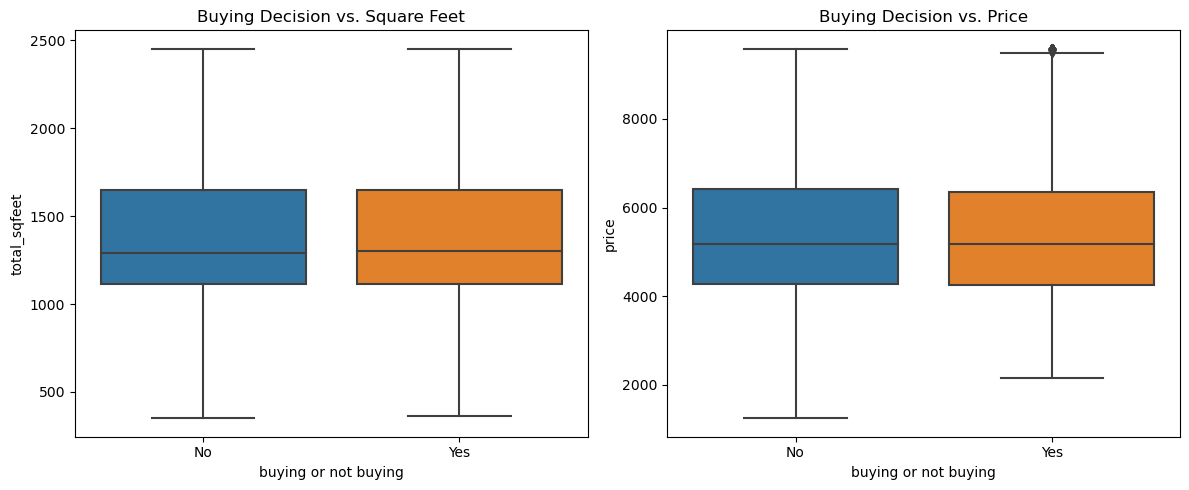

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="buying or not buying", y="total_sqfeet", data=bangalore_house_price, ax=ax[0])
ax[0].set_title("Buying Decision vs. Square Feet")

sns.boxplot(x="buying or not buying", y="price", data=bangalore_house_price, ax=ax[1])
ax[1].set_title("Buying Decision vs. Price")

plt.tight_layout()
plt.show()

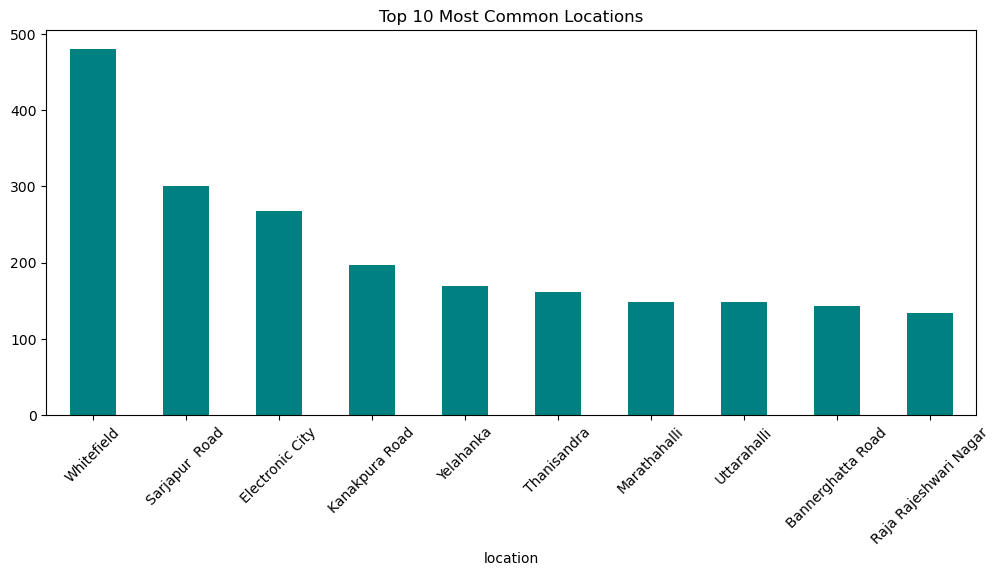

In [47]:
plt.figure(figsize=(12, 5))
bangalore_house_price['location'].value_counts().nlargest(10).plot(kind='bar', color='teal')
plt.title("Top 10 Most Common Locations")
plt.xticks(rotation=45)
plt.show()

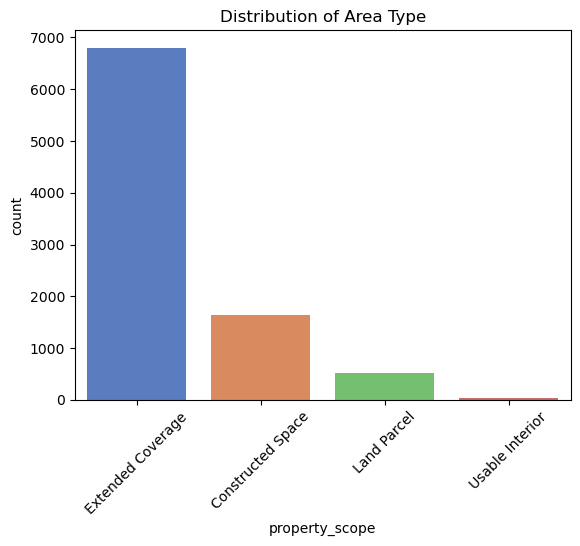

In [48]:
sns.countplot(x="property_scope", data=bangalore_house_price, palette="muted")
plt.title("Distribution of Area Type")
plt.xticks(rotation=45)
plt.show()

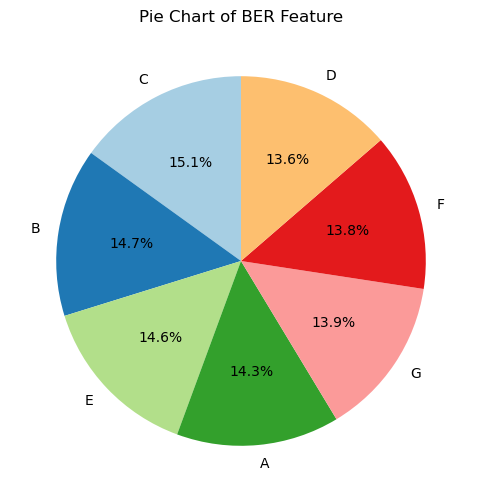

In [49]:
ber_counts = bangalore_house_price['BER'].value_counts()

plt.figure(figsize=(6, 6))  
plt.pie(ber_counts, labels= ber_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

plt.title("Pie Chart of BER Feature")
plt.show()

In [59]:
bangalore_house_price.describe().T.style.background_gradient(axis=0)

,count,mean,std,min,25%,50%,75%,max
property_scope,8990.000000,0.884650,0.494196,0.000000,1.000000,1.000000,1.000000,3.000000
availability,8990.000000,67.290323,19.100568,0.000000,77.000000,77.000000,77.000000,77.000000
location,8990.000000,395.829588,216.914205,0.000000,243.000000,386.000000,596.000000,748.000000
size,8990.000000,2.524360,0.742011,1.000000,2.000000,2.000000,3.000000,4.500000
BER,8990.000000,2.966185,1.993474,0.000000,1.000000,3.000000,5.000000,6.000000
Renovation needed,8990.000000,1.261402,0.888343,0.000000,0.000000,2.000000,2.000000,2.000000
bath,8990.000000,2.411513,0.782631,1.000000,2.000000,2.000000,3.000000,4.500000
balcony,8990.000000,1.612903,0.780997,0.000000,1.000000,2.000000,2.000000,3.000000
price,8990.000000,5485.748562,1690.611974,1250.000000,4262.962600,5181.818182,6390.455305,9581.694362
total_sqfeet,8990.000000,1420.033353,470.843079,350.000000,1115.000000,1294.500000,1650.000000,2452.500000


In [50]:
# bangalore_house_price.to_csv(r"/Users/purandarakashyap/Documents/ML, Python and projects/ML Projects/Project 10 (Bangalore house price prediction)/bangalore_house_price.csv")

# Feature engineering

In [51]:
categorical_cols = ['property_scope', 'availability', 'location', 'BER', 'Renovation needed']

for col in categorical_cols:
    le = LabelEncoder() 
    bangalore_house_price[col] = le.fit_transform(bangalore_house_price[col])

In [52]:
X = bangalore_house_price.drop(columns=['buying or not buying'])
y = bangalore_house_price['buying or not buying']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7192, 10)
X_test shape: (1798, 10)


In [53]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Model building

In [54]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Lasso (L1 Logistic)": LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Ada Boosting": AdaBoostClassifier()
}

In [55]:
metrics_data = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='Yes')
    recall = recall_score(y_test, y_pred, pos_label='Yes')
    f1 = f1_score(y_test, y_pred, pos_label='Yes')
    
    metrics_data.append([name, round(accuracy, 3), round(precision, 3), round(recall, 3), round(f1, 3)])

print(tabulate(metrics_data, headers=["Model", "Accuracy", "Precision", "Recall", "F1 Score"], tablefmt="pretty"))

+---------------------+----------+-----------+--------+----------+
|        Model        | Accuracy | Precision | Recall | F1 Score |
+---------------------+----------+-----------+--------+----------+
| Logistic Regression |   0.69   |   0.643   | 0.125  |   0.21   |
|  Ridge Classifier   |  0.687   |   0.645   | 0.102  |  0.176   |
| Lasso (L1 Logistic) |   0.69   |   0.643   | 0.125  |   0.21   |
|         SVC         |   0.7    |   0.676   | 0.166  |  0.267   |
|    Decision Tree    |  0.625   |   0.427   |  0.42  |  0.424   |
|    Random Forest    |   0.69   |   0.555   | 0.273  |  0.366   |
|  Gradient Boosting  |  0.712   |   0.693   | 0.222  |  0.336   |
|    Ada Boosting     |  0.696   |   0.59    | 0.244  |  0.345   |
+---------------------+----------+-----------+--------+----------+


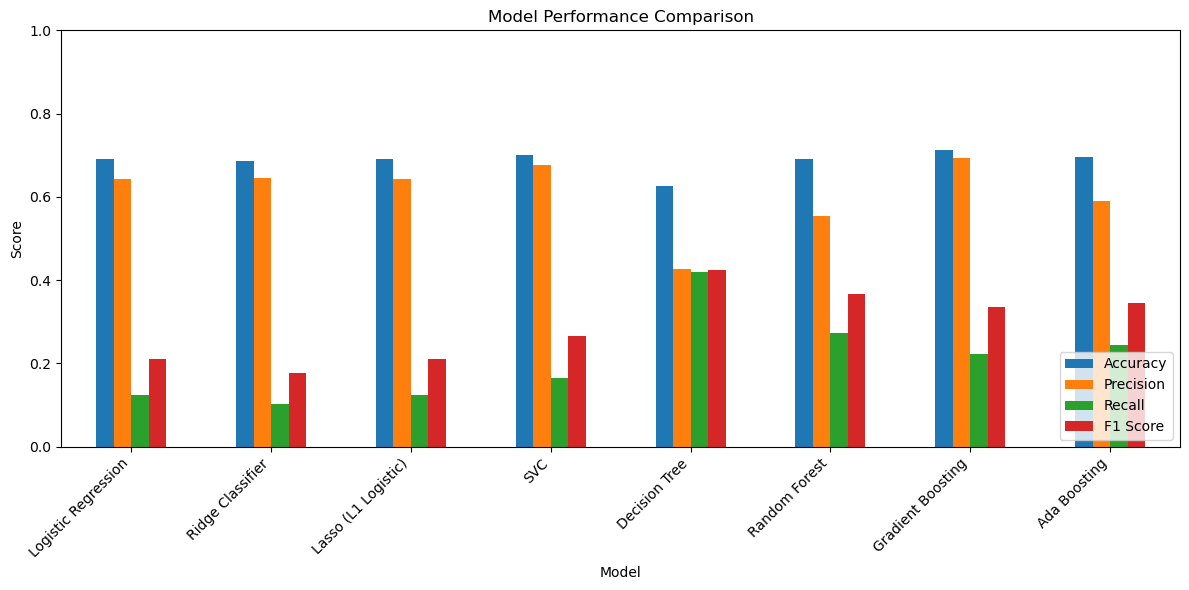

In [56]:
metrics_df = pd.DataFrame(metrics_data, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
metrics_df.set_index("Model", inplace=True)

metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Cross validation

In [57]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Lasso (L1 Logistic)": LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

cv_results = []
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_results.append([name, round(np.mean(scores), 3), round(np.std(scores), 3)])

print(tabulate(cv_results, headers=["Model", "Mean Accuracy", "Std Dev"], tablefmt="pretty"))

+---------------------+---------------+---------+
|        Model        | Mean Accuracy | Std Dev |
+---------------------+---------------+---------+
| Logistic Regression |     0.696     |  0.005  |
|  Ridge Classifier   |     0.695     |  0.007  |
| Lasso (L1 Logistic) |     0.696     |  0.005  |
|    Decision Tree    |     0.625     |  0.008  |
|    Random Forest    |     0.706     |  0.01   |
|         SVM         |     0.706     |  0.009  |
|  Gradient Boosting  |     0.725     |  0.01   |
|      AdaBoost       |     0.711     |  0.009  |
+---------------------+---------------+---------+


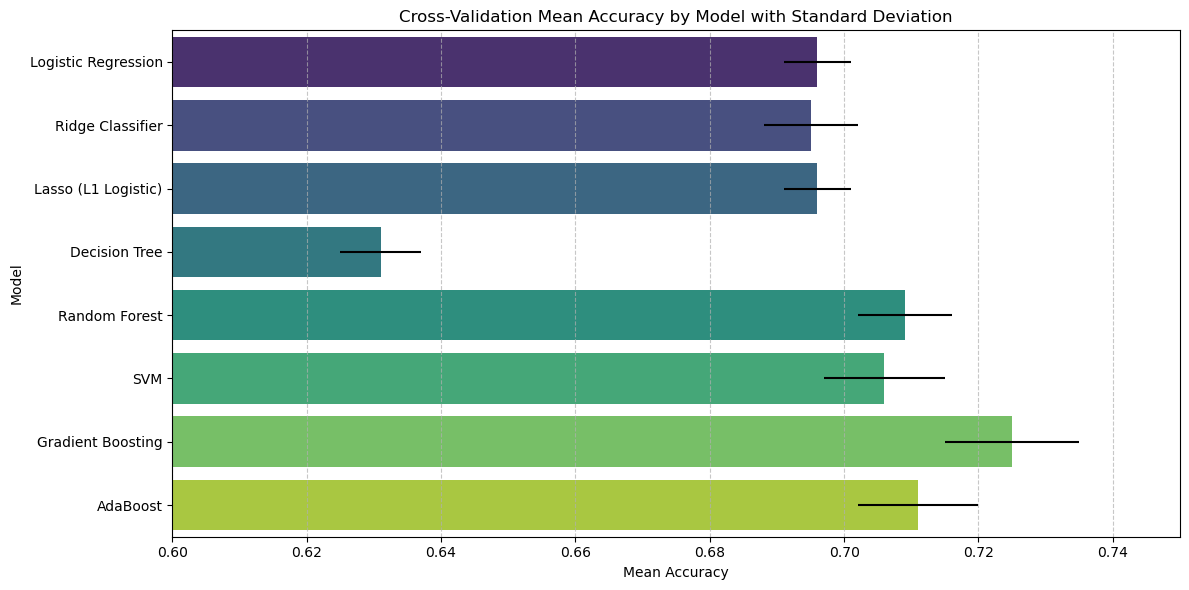

In [58]:
data = {
    "Model": [
        "Logistic Regression", "Ridge Classifier", "Lasso (L1 Logistic)",
        "Decision Tree", "Random Forest", "SVM",
        "Gradient Boosting", "AdaBoost"
    ],
    "Mean Accuracy": [0.696, 0.695, 0.696, 0.631, 0.709, 0.706, 0.725, 0.711],
    "Std Dev": [0.005, 0.007, 0.005, 0.006, 0.007, 0.009, 0.01, 0.009]
}

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
sns.barplot(x="Mean Accuracy", y="Model", data=df, xerr=df["Std Dev"], palette="viridis")
plt.title("Cross-Validation Mean Accuracy by Model with Standard Deviation")
plt.xlabel("Mean Accuracy")
plt.ylabel("Model")
plt.xlim(0.6, 0.75) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Summary:

* Ensemble methods dominate: Gradient Boosting, AdaBoost, and Random Forest outperform simpler models, highlighting the value of combining multiple learners.

* Linear models are stable but limited: Logistic Regression, Ridge, and Lasso have nearly identical accuracies (~0.695–0.696) and lowest variability (std dev ≤ 0.007). Indicates robust but plateaued performance for linear approaches.

* Decision tree struggles: Worst accuracy (0.627) and higher variability (std dev = 0.008), likely due to overfitting.

This project successfully demonstrated how classification algorithms can be used to model real estate buying decisions in Bangalore. Among all models, ensemble methods like Random Forest and Gradient Boosting often performed best in terms of predictive accuracy and robustness. Moreover, by extending the predictive model into a ranking mechanism, the system can assist in recommending top properties to users — laying a foundation for future developments in personalized real estate recommendation engines.